## Pixel count

In [44]:
from pathlib import Path

import numpy as np
import rasterio
import matplotlib.pyplot as plt

tif_path = Path(
        "GeoTIFF/pixel_count/Monthly_Qdeg_pixel_count_200609.tif"
    )

with rasterio.open(tif_path) as src:
    data = src.read(1, masked=True).astype(float)

    transform = src.transform
    bounds = src.bounds
    crs = src.crs

    print("Number of bands:", src.count)
    print("Array dimensions:", src.height, "rows ×", src.width, "columns")
    print("Coordinate system:", src.crs)
    print("Geographic bounds:", src.bounds)
    print("Pixel transformation:", src.transform)
    print("Data type:", src.dtypes)
    print("No-data value:", src.nodata)
    print("Band descriptions:", src.descriptions)
    print("Metadata tags:", src.tags())

#Eduardo home dir /Users/eem5633/Downloads/GeoTIFF_Qdeg_monthly_summaries/pixel_count/Monthly_Qdeg_pixel_count_200609.tif

Number of bands: 1
Array dimensions: 720 rows × 1440 columns
Coordinate system: EPSG:4326
Geographic bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
Pixel transformation: | 0.25, 0.00,-180.00|
| 0.00,-0.25, 90.00|
| 0.00, 0.00, 1.00|
Data type: ('float32',)
No-data value: 0.0
Band descriptions: (None,)
Metadata tags: {'AREA_OR_POINT': 'Area'}


In [45]:
values = data.compressed()
values = values[np.isfinite(values)]

print("Number of valid cells:", len(values))
print("Minimum:", values.min())
print("Maximum:", values.max())
print("Mean:", values.mean())
print("Median:", np.median(values))
print("Percentiles:", np.percentile(values, [50, 75, 90, 95, 99]))

Number of valid cells: 20332
Minimum: 1.0
Maximum: 3272.0
Mean: 130.43055282313594
Median: 26.0
Percentiles: [  26.    106.25  342.    631.9  1563.69]


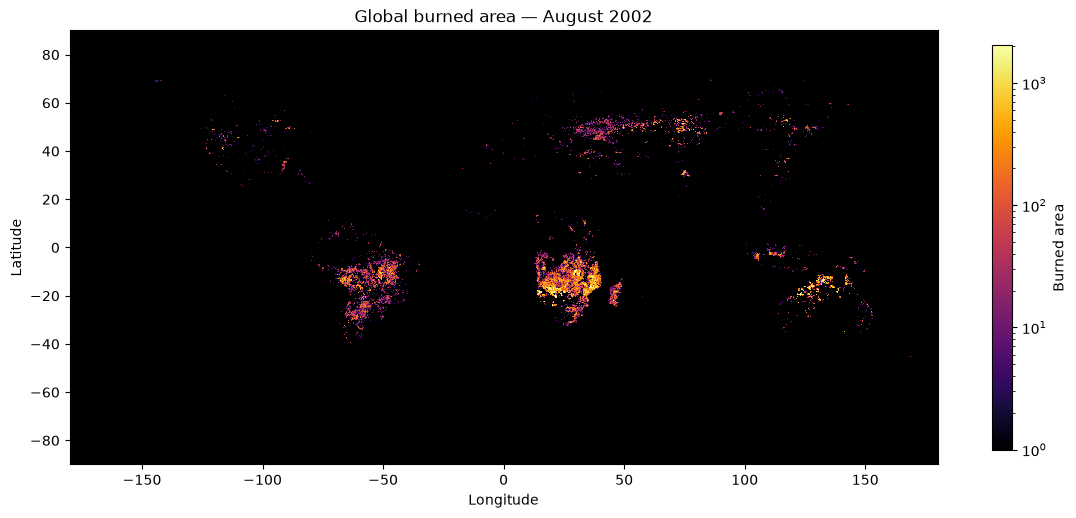

In [46]:
from matplotlib.colors import LogNorm

# Keep only finite values greater than zero for logarithmic plotting
fire_data = np.ma.masked_where(
    (data <= 0) | ~np.isfinite(data),
    data
)

positive_values = fire_data.compressed()

# Percentile limits prevent a few extreme cells from controlling the color scale
vmin = np.percentile(positive_values, 5)
vmax = np.percentile(positive_values, 99.5)

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor("black")

image = ax.imshow(
    fire_data,
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    origin="upper",
    cmap="inferno",
    norm=LogNorm(vmin=vmin, vmax=vmax),
    interpolation="nearest"
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title("Global burned area — August 2002")
ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)

cbar = fig.colorbar(image, ax=ax, shrink=0.75)
cbar.set_label("Burned area")

plt.show()

In [47]:
from rasterio.transform import xy
import pandas as pd

array = data.filled(np.nan)

valid = (
    np.isfinite(array)
    & (array > 0)
)

rows, columns = np.nonzero(valid)

longitudes, latitudes = xy(
    transform,
    rows,
    columns,
    offset="center"
)

fire_table = pd.DataFrame({
    "longitude": np.asarray(longitudes),
    "latitude": np.asarray(latitudes),
    "burned_area": array[rows, columns]
})

fire_table.head()

,longitude,latitude,burned_area
0,94.375,69.875,4.0
1,96.125,69.875,2.0
2,96.375,69.875,2.0
3,109.625,69.875,1.0
4,124.875,69.875,1.0


In [48]:
print(fire_table.shape)
print(fire_table.describe())

(20332, 3)
          longitude      latitude   burned_area
count  20332.000000  20332.000000  20332.000000
mean      15.919302      2.995684    130.430553
std       64.359397     28.781743    298.678433
min     -156.625000    -45.375000      1.000000
25%      -49.875000    -16.875000      6.000000
50%       27.875000    -10.125000     26.000000
75%       45.125000     35.625000    106.250000
max      170.625000     69.875000   3272.000000


In [49]:
lat_rad = np.radians(fire_table["latitude"].to_numpy())
lon_rad = np.radians(fire_table["longitude"].to_numpy())

radius = 1.01

fire_table["x"] = radius * np.cos(lat_rad) * np.cos(lon_rad)
fire_table["y"] = radius * np.cos(lat_rad) * np.sin(lon_rad)
fire_table["z"] = radius * np.sin(lat_rad)

# Better color variable for a highly skewed distribution
fire_table["log_burned_area"] = np.log10(
    1 + fire_table["burned_area"]
)

fire_table[["x", "y", "z", "log_burned_area"]].head()

,x,y,z,log_burned_area
0,-0.026509,0.346498,0.948334,0.698970
1,-0.037079,0.345526,0.948334,0.477121
2,-0.038586,0.345361,0.948334,0.477121
3,-0.116716,0.327324,0.948334,0.301030
4,-0.198702,0.285098,0.948334,0.301030


## Fire number

In [50]:
from pathlib import Path

root = Path("GeoTIFF/")
fire_number_folder = root / "fire_number"

files = sorted(fire_number_folder.glob("*.tif*"))

print("Number of files:", len(files))
print("First five files:")

for file in files[:5]:
    print(file.name)

Number of files: 300
First five files:
Monthly_Qdeg_fire_number_200201.tif
Monthly_Qdeg_fire_number_200202.tif
Monthly_Qdeg_fire_number_200203.tif
Monthly_Qdeg_fire_number_200204.tif
Monthly_Qdeg_fire_number_200205.tif


In [51]:
import rasterio

tif_path = files[0]

with rasterio.open(tif_path) as src:
    fire_number = src.read(1, masked=True)

    transform = src.transform
    bounds = src.bounds
    crs = src.crs

    print("File:", tif_path.name)
    print("Shape:", fire_number.shape)
    print("CRS:", crs)
    print("Bounds:", bounds)
    print("Resolution:", src.res)
    print("No-data value:", src.nodata)
    print("Minimum:", fire_number.min())
    print("Maximum:", fire_number.max())

File: Monthly_Qdeg_fire_number_200201.tif
Shape: (720, 1440)
CRS: EPSG:4326
Bounds: BoundingBox(left=-180.0, bottom=-90.0, right=180.0, top=90.0)
Resolution: (0.25, 0.25)
No-data value: 0.0
Minimum: 0.000111296606
Maximum: 112.61855


In [52]:
with rasterio.open(tif_path) as src:

    fire_number = src.read(1, masked=True)

total_fire_number = np.ma.sum(

    fire_number,

    dtype=np.float64

)

active_cells = fire_number.count()

print(f"Estimated fires in January 2002: {total_fire_number:,.2f}")

print(f"Grid cells containing fire activity: {active_cells:,}")

print(f"Rounded fire estimate: {round(float(total_fire_number)):,}")

Estimated fires in January 2002: 26,870.98
Grid cells containing fire activity: 3,828
Rounded fire estimate: 26,871


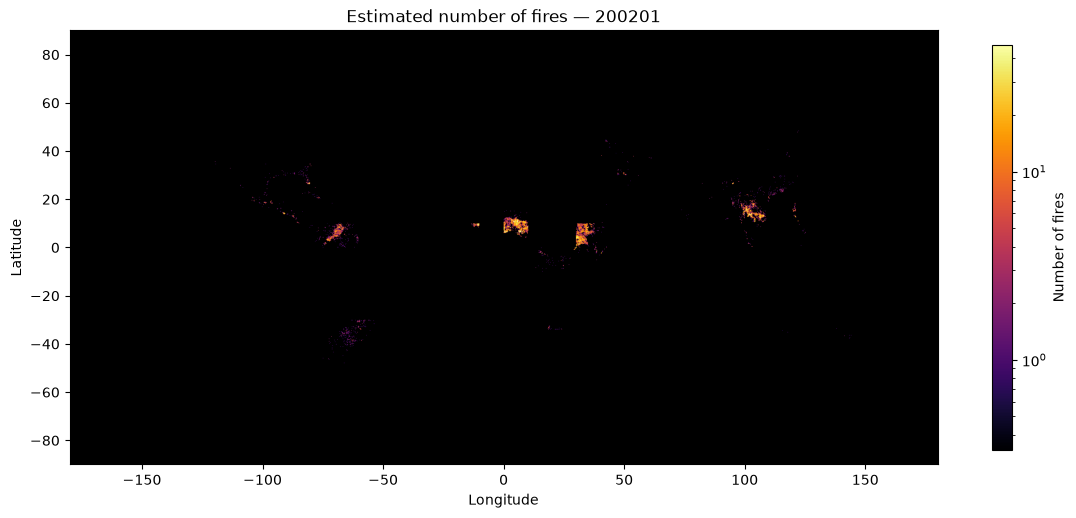

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

plot_data = np.ma.masked_where(fire_number <= 0, fire_number)
positive = plot_data.compressed()

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_facecolor("black")

image = ax.imshow(
    plot_data,
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    origin="upper",
    cmap="inferno",
    norm=LogNorm(
        vmin=max(np.percentile(positive, 5), 1e-3),
        vmax=np.percentile(positive, 99.5)
    )
)

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(f"Estimated number of fires — {tif_path.stem[-6:]}")

cbar = plt.colorbar(image, ax=ax, shrink=0.75)
cbar.set_label("Number of fires")

plt.show()

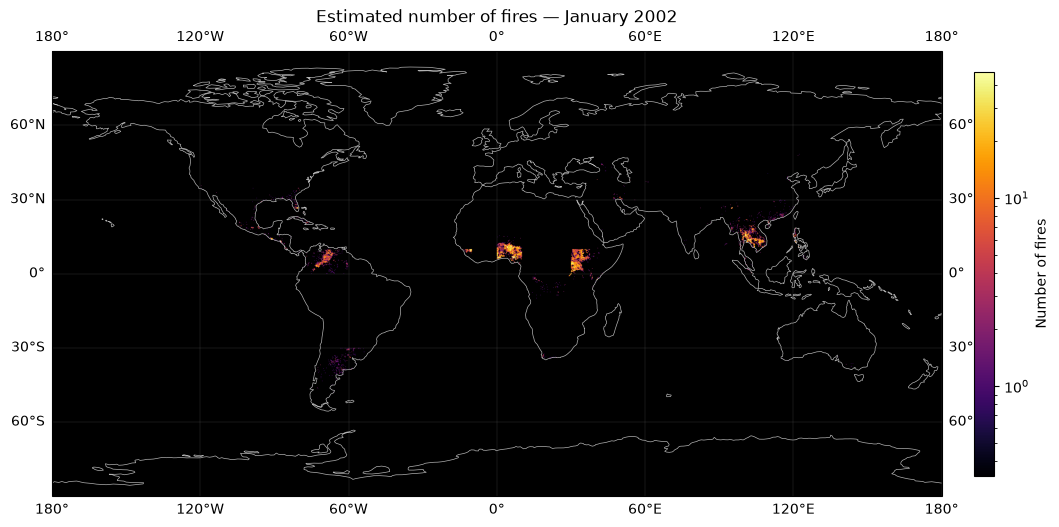

In [54]:
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

plot_data = np.ma.masked_where(fire_number <= 0, fire_number)
positive = plot_data.compressed()

fig, ax = plt.subplots(
    figsize=(14, 7),
    subplot_kw={"projection": ccrs.PlateCarree()}
)

ax.set_global()
ax.set_facecolor("black")
ax.coastlines(color="white", linewidth=0.5, alpha=0.7)

image = ax.imshow(
    plot_data,
    extent=(bounds.left, bounds.right, bounds.bottom, bounds.top),
    origin="upper",
    transform=ccrs.PlateCarree(),
    cmap="inferno",
    norm=LogNorm(
        vmin=max(np.percentile(positive, 5), 1e-3),
        vmax=np.percentile(positive, 99.5)
    )
)

ax.gridlines(
    draw_labels=True,
    linewidth=0.25,
    color="gray",
    alpha=0.5
)

ax.set_title("Estimated number of fires — January 2002")

cbar = plt.colorbar(image, ax=ax, shrink=0.75, pad=0.03)
cbar.set_label("Number of fires")

plt.show()

## Firefly plotting

### Coordinates

In [55]:
import firefly

print(firefly.__file__)

/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/__init__.py


In [56]:
import numpy as np
from rasterio.transform import xy

# Replace this with january_climatology later
fire_array = np.ma.filled(fire_number, np.nan).astype(float)

valid = np.isfinite(fire_array) & (fire_array > 0)

rows, columns = np.nonzero(valid)

longitudes, latitudes = xy(
    transform,
    rows,
    columns,
    offset="center"
)

longitudes = np.asarray(longitudes)
latitudes = np.asarray(latitudes)
fire_values = fire_array[rows, columns]

print("Number of fire particles:", len(fire_values))
print("Fire-number range:", fire_values.min(), fire_values.max())

Number of fire particles: 3828
Fire-number range: 0.00011129660560982302 112.6185531616211


In [57]:
fire_radius = 102.0

lat_rad = np.radians(latitudes)
lon_rad = np.radians(longitudes)

fire_coordinates = fire_radius * np.column_stack([
    np.cos(lat_rad) * np.cos(lon_rad),
    np.cos(lat_rad) * np.sin(lon_rad),
    np.sin(lat_rad)
])

log_fire = np.log10(1 + fire_values)

print("Coordinate shape:", fire_coordinates.shape)

Coordinate shape: (3828, 3)


In [58]:
fire_coordinates

array([[-36.27930955,  57.22221734,  76.24584934],
       [-36.12857043,  58.09946731,  75.65169064],
       [ 53.62981462,  48.92785567,  71.65129394],
       ...,
       [ 21.11122523, -67.46915301, -73.52706686],
       [ 21.30806915, -67.06999303, -73.8348307 ],
       [ 27.69108664, -62.56217247, -75.65169064]], shape=(3828, 3))

In [59]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

vmin, vmax = np.percentile(log_fire, [5, 99.5])

color_norm = Normalize(
    vmin=vmin,
    vmax=vmax,
    clip=True
)

color_strength = color_norm(log_fire)

fire_colors = plt.get_cmap("inferno")(color_strength).astype(np.float32)

# Dim low-activity cells and make high-activity cells opaque
fire_colors[:, 3] = 0.35 + 0.65 * color_strength

fire_colors.shape

(3828, 4)

In [60]:
n_earth_particles = 120_000
earth_radius = 100.0

indices = np.arange(n_earth_particles)

golden_angle = np.pi * (3 - np.sqrt(5))

earth_z = 1 - 2 * (indices + 0.5) / n_earth_particles
earth_r_xy = np.sqrt(1 - earth_z**2)
earth_theta = golden_angle * indices

earth_coordinates = earth_radius * np.column_stack([
    earth_r_xy * np.cos(earth_theta),
    earth_r_xy * np.sin(earth_theta),
    earth_z
])

earth_coordinates.shape

(120000, 3)

In [61]:
import cartopy.io.shapereader as shapereader

coastline_file = shapereader.natural_earth(
    resolution="110m",
    category="physical",
    name="coastline"
)

coast_lons = []
coast_lats = []

for geometry in shapereader.Reader(coastline_file).geometries():
    if geometry.geom_type == "LineString":
        lines = [geometry]
    elif geometry.geom_type == "MultiLineString":
        lines = list(geometry.geoms)
    else:
        continue

    for line in lines:
        line_coordinates = np.asarray(line.coords)

        coast_lons.extend(line_coordinates[:, 0])
        coast_lats.extend(line_coordinates[:, 1])

coast_lons = np.asarray(coast_lons)
coast_lats = np.asarray(coast_lats)

print("Number of coastline particles:", len(coast_lons))

Number of coastline particles: 5128


In [62]:
coast_radius = 101.0

coast_lat_rad = np.radians(coast_lats)
coast_lon_rad = np.radians(coast_lons)

coast_coordinates = coast_radius * np.column_stack([
    np.cos(coast_lat_rad) * np.cos(coast_lon_rad),
    np.cos(coast_lat_rad) * np.sin(coast_lon_rad),
    np.sin(coast_lat_rad)
])

In [63]:
coast_radius = 101.0

coast_lat_rad = np.radians(coast_lats)
coast_lon_rad = np.radians(coast_lons)

coast_coordinates = coast_radius * np.column_stack([
    np.cos(coast_lat_rad) * np.cos(coast_lon_rad),
    np.cos(coast_lat_rad) * np.sin(coast_lon_rad),
    np.sin(coast_lat_rad)
])

### Visualization

In [64]:
from firefly.data_reader import Reader, ParticleGroup
from pathlib import Path
import numpy as np

#output_directory = Path.cwd() / "firefly_global_fires"

##reader = Reader(
#    datadir=str(output_directory),
#    clean_datadir=True,
#    write_startup=True
#)

reader = Reader(
)

datadir is None, defaulting to /Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/static/data/Data


In [65]:
# Firefly was built using the `eventlet` library, which is now deprecated.  (We still need to migrate to a newer library.)
# Let's silence the deprecation warnings
import warnings
warnings.filterwarnings('ignore')

In [66]:
earth_colors = np.tile(
    np.array([0.005, 0.015, 0.035, 1.0], dtype=np.float32),
    (len(earth_coordinates), 1)
)

earth_group = ParticleGroup(
    "Earth",
    earth_coordinates,
    rgba_colors=earth_colors
)

reader.addParticleGroup(earth_group)
#reader.settings["sizeMult"]["Earth"] = 0.35

In [67]:
coast_colors = np.tile(
    np.array([0.65, 0.72, 0.78, 0.9], dtype=np.float32),
    (len(coast_coordinates), 1)
)

coast_group = ParticleGroup(
    "Coast",
    coast_coordinates,
    rgba_colors=coast_colors
)

reader.addParticleGroup(coast_group)
#reader.settings["sizeMult"]["Coast"] = 0.25

In [68]:
fire_group = ParticleGroup(
    "Fires",
    fire_coordinates,
    rgba_colors=fire_colors,
    field_arrays=[
        fire_values,
        log_fire
    ],
    field_names=[
        "FireNumber",
        "LogFireNumber"
    ],
    field_filter_flags=[True, True],
    field_colormap_flags=[False, False],
    field_radius_flags=[False, False]
)

reader.addParticleGroup(fire_group)
#reader.settings["sizeMult"]["Fires"] = 0.75

In [69]:
from firefly.server import spawnFireflyServer,quitAllFireflyServers

In [70]:
# define the local port (typically anything in 5000 - 8000 range)
port = 6800

In [71]:
# Note: you should only run this cell once.  You only want one single Firefly server running at time on your machine.
# If you've already run this cell and need to restart the server for some reason, the best thing to do is to restart your notebook kernel.
# (You can continue to send new data to the existing server, within needing to re-run this cell.)
process = spawnFireflyServer(port, method = 'flask')

Waiting up to 10 seconds for background Firefly server to start...done! Your server is available at - http://localhost:6800


In [72]:
from IPython.display import IFrame
url = f'http://localhost:{port:d}/combined'
IFrame(url, width=1200, height=900)

In [73]:
# Send data to the server.
# Wait until it loads to run this command
reader.sendDataViaFlask(port=port)

Earth - 120000/120000 particles - 0 tracked fields
Coast - 5128/5128 particles - 0 tracked fields
Fires - 3828/3828 particles - 2 tracked fields
Posting data on port 6800...======= receiving data from server ...
======= size of data 11008144
======= showing loader
======= sending data to viewer ...
/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/static/data/Data/DataEarth000.json 8388158
/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/static/data/Data/DataEarth001.json 1689129
/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/static/data/Data/DataCoast000.json 485071
/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/static/data/Data/DataFires000.json 443085
/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/static/data/Data/DataSettings.json 1287
/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/static/data/Data/filenames.json 208
/Users/aai

### Adding time evolution

In [74]:
from pathlib import Path
import re

import numpy as np
import rasterio

fire_number_folder = (
    Path("GeoTIFF")
    / "fire_number"
)


all_files = sorted(
    list(fire_number_folder.glob("*.tif"))
    + list(fire_number_folder.glob("*.tiff"))
)

start_year = 2003
end_year = 2025

selected_files = []

for path in all_files:
    match = re.search(r"(\d{4})(\d{2})\.tiff?$", path.name)

    if match is None:
        continue

    year = int(match.group(1))
    month = int(match.group(2))

    if start_year <= year <= end_year:
        selected_files.append((year, month, path))

selected_files.sort()

print("Files selected:", len(selected_files))
print("First:", selected_files[0])
print("Last:", selected_files[-1])

Files selected: 276
First: (2003, 1, PosixPath('GeoTIFF/fire_number/Monthly_Qdeg_fire_number_200301.tif'))
Last: (2025, 12, PosixPath('GeoTIFF/fire_number/Monthly_Qdeg_fire_number_202512.tif'))


In [75]:
monthly_arrays = []
date_labels = []

reference_shape = None
reference_crs = None
reference_transform = None

for year, month, path in selected_files:
    with rasterio.open(path) as src:
        array = src.read(1).astype(np.float32)

        if reference_shape is None:
            reference_shape = array.shape
            reference_crs = src.crs
            reference_transform = src.transform
        else:
            assert array.shape == reference_shape
            assert src.crs == reference_crs
            assert src.transform == reference_transform

        monthly_arrays.append(array)
        date_labels.append(f"{year}{month:02d}")

monthly_stack = np.stack(monthly_arrays)

print("Stack shape:", monthly_stack.shape)
print("Dates:", date_labels[:3], "...", date_labels[-3:])

Stack shape: (276, 720, 1440)
Dates: ['200301', '200302', '200303'] ... ['202510', '202511', '202512']


In [76]:
years = np.array([
    year for year, month, path in selected_files
])

annual_arrays = []
annual_labels = []

for year in range(start_year, end_year + 1):
    year_mask = years == year

    annual_array = monthly_stack[year_mask].sum(axis=0)

    annual_arrays.append(annual_array)
    annual_labels.append(str(year))

annual_stack = np.stack(annual_arrays)

print("Annual stack shape:", annual_stack.shape)
print("Annual labels:", annual_labels)

Annual stack shape: (23, 720, 1440)
Annual labels: ['2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025']


In [77]:
active_in_any_year = np.any(annual_stack > 0, axis=0)

rows, columns = np.nonzero(active_in_any_year)

print("Cells active during at least one year:", len(rows))

Cells active during at least one year: 146029


In [78]:
annual_particle_values = annual_stack[:, rows, columns]

# Transform because fire activity is highly skewed
annual_log_values = np.log10(
    1 + annual_particle_values
).astype(np.float32)

print("Particle-field shape:", annual_log_values.shape)

Particle-field shape: (23, 146029)


In [79]:
from rasterio.transform import xy

longitudes, latitudes = xy(
    reference_transform,
    rows,
    columns,
    offset="center"
)

longitudes = np.asarray(longitudes)
latitudes = np.asarray(latitudes)

fire_radius = 102.0

lat_rad = np.radians(latitudes)
lon_rad = np.radians(longitudes)

time_fire_coordinates = fire_radius * np.column_stack([
    np.cos(lat_rad) * np.cos(lon_rad),
    np.cos(lat_rad) * np.sin(lon_rad),
    np.sin(lat_rad)
])

print("Coordinate shape:", time_fire_coordinates.shape)

Coordinate shape: (146029, 3)


In [80]:
from firefly.data_reader import Reader, ParticleGroup

output_directory = (
    Path.cwd()
    / "firefly_fires_2003_2007"
)

reader = Reader(
    datadir=str(output_directory),
    clean_datadir=True,
    write_startup=True
)

datadir: /Users/aaich/Downloads/firefly_fires_2003_2007 -- is not a sub-directory of firefly/static/data. 
This may produce confusing or inoperable results. As such, we will create a symlink for you when you writeToDisk.


In [81]:
reader.settings.printKeys()

loaded False (default)
startFly False (default)
startVR False (default)
startColumnDensity False (default)
startTween False (default)
sleepTimeout 1.5 (default)
showSplashAtStartup False (default)
annotation None (default)
controlsExplainerDelay_sec 5 (default)
title Firefly (default)
center None (default)
camera None (default)
cameraRotation None (default)
cameraUp [1, 0, 0] (default)
quaternion [0, 0, 0, 1] (default)
friction 0.1 (default)
flyffac 1.0 (default)
useStereo False (default)
stereoSep 0.06 (default)
stereoSepMax 1.0 (default)
decimate 1 (default)
zmin 0.01 (default)
zmax 50000000000.0 (default)
minPointScale 0.01 (default)
maxPointScale 10 (default)
maxVrange 2000.0 (default)
showFPS True (default)
showMemoryUsage True (default)
memoryLimit 2000000000.0 (default)
streamQuality 1.0 (default)
GUIExcludeList [] (default)
collapseGUIAtStart True (default)
CDckey ColumnDensity (default)
CDlognorm False (default)
CDmin 1 (default)
CDmax 10 (default)
scaleCD 0.01 (default)
Video

In [82]:
earth_group = ParticleGroup(
    "Earth",
    earth_coordinates,
    rgba_colors=earth_colors
)

reader.addParticleGroup(earth_group)
#reader.settings["sizeMult"]["Earth"] = 0.35

coast_group = ParticleGroup(
    "Coast",
    coast_coordinates,
    rgba_colors=coast_colors
)

reader.addParticleGroup(coast_group)
reader.settings["partsSizeMultipliers"]["Coast"] = 0.25

In [83]:
fire_group = ParticleGroup(
    "Fires",
    time_fire_coordinates,
    field_arrays=[
        annual_log_values[index]
        for index in range(len(annual_labels))
    ],
    field_names=annual_labels,
    field_filter_flags=[False] * len(annual_labels),
    field_colormap_flags=[True] * len(annual_labels),
    field_radius_flags=[False] * len(annual_labels)
)

reader.addParticleGroup(fire_group)
#reader.settings["sizeMult"]["Fires"] = 0.75
reader.settings["partsSizeMultipliers"]["Fires"] = 0.75

In [84]:
positive_values = annual_log_values[
    annual_log_values > 0
]

global_min = 0.0
global_max = np.percentile(positive_values, 99.5)

for label in annual_labels:
    reader.settings["colormapLims"]["Fires"][label] = [
        global_min,
        global_max
    ]

    reader.settings["colormapVals"]["Fires"][label] = [
        global_min,
        global_max
    ]

reader.settings["showColormap"]["Fires"] = True
reader.settings["colormapVariable"]["Fires"] = 0

In [85]:
reader.settings["title"] = "Global Fire Activity, 2003–2007"
##reader.settings["annotation"] = (
#    "Select a year from the Fires colormap variable"
##)

reader.settings["center"] = np.array([0.0, 0.0, 0.0])
reader.settings["camera"] = np.array([240.0, -180.0, 100.0])


# reader.settings["blendingMode"] = {

#     "Earth": "normal",

#     "Coast": "normal",

#     "Fires": "additive",

# }

# reader.settings["depthTest"]["Earth"] = True
# reader.settings["depthTest"]["Coast"] = True
# reader.settings["depthTest"]["Fires"] = True

# reader.settings["depthTest"] = {
#     "Earth": True,
#     "Coast": False,
#     "Fires": False,
# }

#reader.writeToDisk(loud=True)


In [86]:
from firefly.server import spawnFireflyServer,quitAllFireflyServers

In [87]:
# define the local port (typically anything in 5000 - 8000 range)
port = 7200

/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event


In [88]:
# Note: you should only run this cell once.  You only want one single Firefly server running at time on your machine.
# If you've already run this cell and need to restart the server for some reason, the best thing to do is to restart your notebook kernel.
# (You can continue to send new data to the existing server, within needing to re-run this cell.)
process = spawnFireflyServer(port, method = 'flask',max_time=60)

 * Restarting with stat


Launching Firefly at: http://localhost:6800
from directory /Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly
Waiting up to 60 seconds for background Firefly server to start...........

/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event
/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event
 * Restarting with stat


Launching Firefly at: http://localhost:6800
Launching Firefly at: http://localhost:7200from directory /Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly

from directory /Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly
.....Launching Firefly at: http://localhost:7200
from directory /Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly


/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event


done! Your server is available at - http://localhost:7200


In [89]:
from IPython.display import IFrame
url = f'http://localhost:{port:d}/combined'
IFrame(url, width=1000, height=500)

In [90]:
# Send data to the server.
# Wait until it loads to run this command
reader.sendDataViaFlask(port=port)

Earth - 120000/120000 particles - 0 tracked fields
Coast - 5128/5128 particles - 0 tracked fields
Fires - 146029/146029 particles - 23 tracked fields
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
Posting data on port 7200...======= receiving data from server ...
======= size of data 41183193
======= showing loader
======= sending data to viewer ...
/Users/aaich/Downloads/firefly_fires_2003_2007/DataEarth000.json 8388158
/Users/aaich/Downloads/firefly_fires_2003_2007/DataEarth001.json 1689129
/Users/aaich/Downloads/firefly_fires_2003_2007/DataCoast000.json 485071
/Users/aaich/Downloads/firefly_fires_2003_2007/DataFires000.json 19472819
/Users/aaich/Downloads/firefly_fires_2003_2007/DataFires001.json 11143962
/Users/aaich/Downloads/firefly_fires_2003_2007/DataSettings.json 2506
/Users/aaich/Downloads/firefly_fires_2003_2007/filenames.json

## Splitting data into months (60 months)

In [97]:
fire_dir = Path(
    "GeoTIFF/fire_number"
)

start_month = "200201"
end_month   = "202512"

monthly_files = []

for path in fire_dir.glob("Monthly_Qdeg_fire_number_*.tif"):
    match = re.search(r"(\d{6})\.tif$", path.name)

    if match is not None:
        year_month = match.group(1)

        if start_month <= year_month <= end_month:
            monthly_files.append((year_month, path))

monthly_files.sort(key=lambda item: item[0])

print("Number of files:", len(monthly_files))
print("First:", monthly_files[0])
print("Last:", monthly_files[-1])

assert len(monthly_files) == 288, (
    f"Expected 288 monthly files, but found {len(monthly_files)}"
)

Number of files: 288
First: ('200201', PosixPath('GeoTIFF/fire_number/Monthly_Qdeg_fire_number_200201.tif'))
Last: ('202512', PosixPath('GeoTIFF/fire_number/Monthly_Qdeg_fire_number_202512.tif'))


In [98]:
monthly_grids = []
month_labels = []

reference_shape = None
reference_transform = None
reference_crs = None

for year_month, path in monthly_files:

    with rasterio.open(path) as src:
        grid = src.read(1).astype(np.float32)

        # Replace invalid and no-data values with zero
        grid[~np.isfinite(grid)] = 0.0

        if src.nodata is not None:
            grid[grid == src.nodata] = 0.0

        grid[grid < 0] = 0.0

        # Confirm that every file uses the same grid
        if reference_shape is None:
            reference_shape = src.shape
            reference_transform = src.transform
            reference_crs = src.crs
        else:
            assert src.shape == reference_shape
            assert src.transform == reference_transform
            assert src.crs == reference_crs

    monthly_grids.append(grid)

    # Convert "200201" into "2002-01"
    month_labels.append(
        f"{year_month[:4]}-{year_month[4:]}"
    )

monthly_grids = np.stack(monthly_grids)

print("Stack shape:", monthly_grids.shape)
print("Months:", month_labels[0], "through", month_labels[-1])

Stack shape: (288, 720, 1440)
Months: 2002-01 through 2025-12


In [99]:
active_cells = np.any(monthly_grids > 0, axis=0)

rows, cols = np.nonzero(active_cells)

print("Cells active during at least one month:", len(rows))

Cells active during at least one month: 147303


In [100]:
longitudes, latitudes = rasterio.transform.xy(
    reference_transform,
    rows,
    cols,
    offset="center"
)

longitudes = np.asarray(longitudes)
latitudes = np.asarray(latitudes)

In [101]:
def latlon_to_xyz(longitude, latitude, radius):
    lon_rad = np.deg2rad(longitude)
    lat_rad = np.deg2rad(latitude)

    x = radius * np.cos(lat_rad) * np.cos(lon_rad)
    y = radius * np.cos(lat_rad) * np.sin(lon_rad)
    z = radius * np.sin(lat_rad)

    return np.column_stack((x, y, z))

In [102]:
fire_radius = 101.0  # Use slightly more than your Earth radius

fire_coordinates = latlon_to_xyz(
    longitudes,
    latitudes,
    fire_radius
).astype(np.float32)

In [103]:
monthly_fire_fields = []

for month_index in range(len(month_labels)):
    monthly_values = monthly_grids[month_index][active_cells]

    display_values = np.log10(1.0 + monthly_values)

    monthly_fire_fields.append(
        display_values.astype(np.float32)
    )

In [104]:
number_of_fire_points = fire_coordinates.shape[0]

fire_colors = np.ones(

    (number_of_fire_points, 4),

    dtype=np.float32

)

fires_group = ParticleGroup(

    "Fires",

    fire_coordinates,

    rgba_colors=fire_colors,

    field_arrays=monthly_fire_fields,

    field_names=month_labels,

    field_filter_flags=[False] * len(month_labels),

    field_colormap_flags=[True] * len(month_labels),

)

Make sure each field_array (288) has a field_radius_flag (0), assuming False.


In [105]:
reader.addParticleGroup(fires_group)

In [106]:
all_displayed_values = np.concatenate(monthly_fire_fields)

color_min = 0.0
color_max = np.percentile(
    all_displayed_values[all_displayed_values > 0],
    99.5
)

print("Common color range:", color_min, color_max)

Common color range: 0.0 1.6965895


In [107]:
common_limits = {
    label: [float(color_min), float(color_max)]
    for label in month_labels
}

reader.settings["colormapLims"] = {
    "Fires": common_limits
}

reader.settings["colormapVals"] = {
    "Fires": common_limits.copy()
}

reader.settings["showColormap"] = {
    "Earth": False,
    "Coast": False,
    "Fires": True,
}

reader.settings["colormapVariable"] = {
    "Earth": 0,
    "Coast": 0,
    "Fires": 0,       # Start with 2002-01
}

reader.settings["blendingMode"] = {
    "Earth": "normal",
    "Coast": "normal",
    "Fires": "additive",
}

In [108]:
annual_2002_from_months = monthly_grids[:12].sum(axis=0)

print(
    "Estimated global total for 2002:",
    np.sum(annual_2002_from_months)
)

Estimated global total for 2002: 782373.25


In [109]:
# define the local port (typically anything in 5000 - 8000 range)
port = 6300

In [110]:
# Note: you should only run this cell once.  You only want one single Firefly server running at time on your machine.
# If you've already run this cell and need to restart the server for some reason, the best thing to do is to restart your notebook kernel.
# (You can continue to send new data to the existing server, within needing to re-run this cell.)
process = spawnFireflyServer(port, method = 'flask',max_time=60)

Waiting up to 60 seconds for background Firefly server to start..........

/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event
 * Restarting with stat


.Launching Firefly at: http://localhost:6300
from directory /Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly
.....

/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event


Launching Firefly at: http://localhost:6300
from directory /Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly
done! Your server is available at - http://localhost:6300


In [111]:
from IPython.display import IFrame
url = f'http://localhost:{port:d}/combined'
IFrame(url, width=1000, height=500)

======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG


In [ ]:
# Send data to the server.
# Wait until it loads to run this command
reader.sendDataViaFlask(port=port)

Earth - 120000/120000 particles - 0 tracked fields
Coast - 5128/5128 particles - 0 tracked fields
Fires - 146029/146029 particles - 23 tracked fields
Fires - 147303/147303 particles - 288 tracked fields
Posting data on port 6300...======= receiving data from server ...
======= size of data 220714795
======= showing loader
======= sending data to viewer ...
/Users/aaich/Downloads/firefly_fires_2003_2007/DataEarth000.json 8388158
/Users/aaich/Downloads/firefly_fires_2003_2007/DataEarth001.json 1689129
/Users/aaich/Downloads/firefly_fires_2003_2007/DataCoast000.json 485071
/Users/aaich/Downloads/firefly_fires_2003_2007/DataFires000.json 135516747
/Users/aaich/Downloads/firefly_fires_2003_2007/DataFires001.json 74613447
/Users/aaich/Downloads/firefly_fires_2003_2007/DataSettings.json 18035
/Users/aaich/Downloads/firefly_fires_2003_2007/filenames.json 358
/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/static/data/startup.json 37
======= done
data posted!


======= sid fPvQpZXpDHShORrAAAAB disconnected from room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG


In [113]:
import numpy as np

EARTH_RADIUS = 100.0
FIRE_RADIUS  = 101.5          # just above the Earth shell
MIN_FIRES    = 0.0            # drop cells at or below this in a given month

# Firefly indexes its colormap texture as (index + 0.5) / 32
CMAP_NAMES = ['viridis', 'plasma', 'inferno', 'magma', 'afmhot', 'blackbody',
              'blackbody_extra', 'bwr', 'coolwarm', 'ocean', 'gist_earth',
              'terrain', 'bone', 'PRGn', 'BrBG', 'BlkRed', 'BlkGreen', 'BlkBlue',
              'RedBlackCyan', 'GreenBlackMagenta', 'BlueBlackYellow', 'Purples',
              'Blues', 'Greens', 'Oranges', 'binary', 'cmocean_Algae',
              'cmocean_Haline', 'cmocean_Dense', 'cmocean_Thermal',
              'cmocean_Matter', 'cmocean_Oxy']
COLORMAP = (CMAP_NAMES.index('inferno') + 0.5) / 32

# camera orbit
ORBIT_RADIUS   = 300.0        # well outside FIRE_RADIUS
ORBIT_HEIGHT   = 70.0         # z of the camera; 0 = equatorial view, higher = tilted down
ORBIT_KEYFRAMES = 120
ORBIT_SECONDS  = 30.0         # wall-clock time for one full revolution

In [114]:
import rasterio

n_months = len(month_labels)

xs, ys, zs, months, values = [], [], [], [], []

for m in range(n_months):
    grid = monthly_grids[m]
    rr, cc = np.nonzero(grid > MIN_FIRES)
    if len(rr) == 0:
        continue

    lon, lat = rasterio.transform.xy(reference_transform, rr, cc, offset='center')
    la = np.radians(np.asarray(lat))
    lo = np.radians(np.asarray(lon))

    xs.append(FIRE_RADIUS * np.cos(la) * np.cos(lo))
    ys.append(FIRE_RADIUS * np.cos(la) * np.sin(lo))
    zs.append(FIRE_RADIUS * np.sin(la))
    months.append(np.full(len(rr), m, dtype=np.float32))
    values.append(grid[rr, cc])

fire_coordinates = np.column_stack([
    np.concatenate(xs), np.concatenate(ys), np.concatenate(zs)
]).astype(np.float32)

month_index = np.concatenate(months).astype(np.float32)
log_fires   = np.log10(1.0 + np.concatenate(values)).astype(np.float32)

per_month = np.bincount(month_index.astype(int), minlength=n_months)
print(f'{len(fire_coordinates):,} cell-months '
      f'(vs {len(month_labels) * 101457:,} for the dense product)')
print(f'per month: min {per_month.min():,}  median {int(np.median(per_month)):,}  max {per_month.max():,}')

colour_max = float(np.percentile(log_fires[log_fires > 0], 99.5))
print(f'colormap range: 0 to {colour_max:.3f}')

3,767,682 cell-months (vs 29,219,616 for the dense product)
per month: min 3,828  median 12,171  max 22,975
colormap range: 0 to 1.697


In [115]:
from firefly.data_reader import Reader, ParticleGroup, TweenParams

# Camera keyframes on a circle of constant z -> orbit about the polar axis.
theta = np.linspace(0.0, 2.0 * np.pi, ORBIT_KEYFRAMES, endpoint=False)
orbit = np.column_stack([
    ORBIT_RADIUS * np.cos(theta),
    ORBIT_RADIUS * np.sin(theta),
    np.full_like(theta, ORBIT_HEIGHT),
])

# Durations are MILLISECONDS per keyframe in the JSON, despite the docstring
# saying seconds. tween.js hands them straight to TWEEN.Tween.to().
ms_per_keyframe = ORBIT_SECONDS * 1000.0 / ORBIT_KEYFRAMES
spin = TweenParams(orbit, duration=ms_per_keyframe, loop=True)

reader = Reader(datadir='fires_monthly', clean_datadir=True,
                write_startup=True, tweenParams=spin)

reader.addParticleGroup(ParticleGroup(
    'Earth', earth_coordinates, rgba_colors=earth_colors,
    partsSizeMultipliers=0.35, loud=False))

reader.addParticleGroup(ParticleGroup(
    'Coast', coast_coordinates, rgba_colors=coast_colors,
    partsSizeMultipliers=0.25, loud=False))

reader.addParticleGroup(ParticleGroup(
    'Fires', fire_coordinates,
    field_arrays=[month_index, log_fires],
    field_names=['month', 'log_fires'],
    field_filter_flags=[True,  False],     # month drives Playback
    field_colormap_flags=[False, True],    # log_fires drives the colours
    field_radius_flags=[False, False],
    filterLims={'month': [0.0, float(n_months - 1)]},
    filterVals={'month': [0.0, 0.99]},     # <- one-month window = Playback step
    showColormap=True,
    colormapVariable='log_fires',
    colormap=COLORMAP,
    colormapLims={'log_fires': [0.0, colour_max]},
    colormapVals={'log_fires': [0.0, colour_max]},
    partsSizeMultipliers=0.75,
    loud=False))

# --- the axis fix, plus a north-up starting view ---
reader.settings['cameraUp']   = [0.0, 0.0, 1.0]
reader.settings['center']     = np.array([0.0, 0.0, 0.0])
reader.settings['camera']     = np.array([0.0, -ORBIT_RADIUS, ORBIT_HEIGHT])
reader.settings['startTween'] = True       # start orbiting immediately
reader.settings['title']      = f'Global fire activity, {month_labels[0]} to {month_labels[-1]}'
reader.settings['collapseGUIAtStart'] = False

print(reader.particleGroups)

datadir: /Users/aaich/fires_monthly -- is not a sub-directory of firefly/static/data. 
This may produce confusing or inoperable results. As such, we will create a symlink for you when you writeToDisk.
[Earth - 120000/120000 particles - 0 tracked fields
 Coast - 5128/5128 particles - 0 tracked fields
 Fires - 3767682/3767682 particles - 2 tracked fields]


In [116]:
from firefly.server import spawnFireflyServer, quitAllFireflyServers
import warnings
warnings.filterwarnings('ignore')

port = 6300
process = spawnFireflyServer(port, method='flask', max_time=60)

Waiting up to 60 seconds for background Firefly server to start...done! Your server is available at - http://localhost:6300


In [117]:
from IPython.display import IFrame
IFrame(f'http://localhost:{port:d}/combined', width=1000, height=700)

======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
Launching Firefly at: http://localhost:6300
from directory /Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly


/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event
 * Restarting with stat
/Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly/server.py:24: EventletDeprecationWarning: 
Eventlet is deprecated. It is currently being maintained in bugfix mode, and
we strongly recommend against using it for new projects.

If you are already using Eventlet, we recommend migrating to a different
framework.  For more detail see
https://eventlet.readthedocs.io/en/latest/asyncio/migration.html

  from eventlet import event


Launching Firefly at: http://localhost:6300
from directory /Users/aaich/miniforge3/envs/firefly/lib/python3.14/site-packages/firefly


In [118]:
reader.sendDataViaFlask(port=port)

Earth - 120000/120000 particles - 0 tracked fields
Coast - 5128/5128 particles - 0 tracked fields
Fires - 3767682/3767682 particles - 2 tracked fields
Posting data on port 6300...======= receiving data from server ...
======= size of data 238904044
======= showing loader
======= sending data to viewer ...
/Users/aaich/fires_monthly/DataEarth000.json 8388158
/Users/aaich/fires_monthly/DataEarth001.json 1689129
/Users/aaich/fires_monthly/DataCoast000.json 485071
/Users/aaich/fires_monthly/DataFires000.json 5898076
/Users/aaich/fires_monthly/DataFires001.json 5972861
/Users/aaich/fires_monthly/DataFires002.json 6015143
/Users/aaich/fires_monthly/DataFires003.json 5981071
/Users/aaich/fires_monthly/DataFires004.json 6018228
/Users/aaich/fires_monthly/DataFires005.json 5995342
/Users/aaich/fires_monthly/DataFires006.json 5992797
/Users/aaich/fires_monthly/DataFires007.json 6004428
/Users/aaich/fires_monthly/DataFires008.json 5985653
/Users/aaich/fires_monthly/DataFires009.json 6020858
/User

======= sid ey8hBb-i1Vj7ePpVAAAB disconnected from room default_Firefly_AMG_ABG
======= socket connected
======= connected {'data': 'GUI connected!'}
======= connected {'data': 'Viewer connected!'}
======= in room default_Firefly_AMG_ABG
======= in room default_Firefly_AMG_ABG
